# Python para Saúde e Performance

**Objetivo:** Cruzar múltiplas fontes de dados (Atividade, Sono, Nutrição e Sinais Vitais) para extrair Insights de saúde.

## 1. Ingestão de Dados

Vamos carregar **5 arquivos separados**, simulando o ecossistema real de aplicativos de saúde.

In [1]:
# Importando as bibliotecas essenciais para manipulação e visualização de dados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

# Dica: O tema 'whitegrid' deixa os gráficos mais limpos e profissionais
sns.set_theme(style="whitegrid")

# Lendo os arquivos CSV diretamente do GitHub
# Em um projeto real, esses dados viriam de APIs (ex: Apple Health, Google Fit)
df_act = pd.read_csv('https://raw.githubusercontent.com/jaimecirne/AuldaPythonDadosSaude/refs/heads/main/data/Activity.csv')
df_sleep = pd.read_csv('https://raw.githubusercontent.com/jaimecirne/AuldaPythonDadosSaude/refs/heads/main/data/Sleep.csv')
df_nutri = pd.read_csv('https://raw.githubusercontent.com/jaimecirne/AuldaPythonDadosSaude/refs/heads/main/data/Nutrition.csv')
df_body = pd.read_csv('https://raw.githubusercontent.com/jaimecirne/AuldaPythonDadosSaude/refs/heads/main/data/Body_Measurements.csv')
df_vitals = pd.read_csv('https://raw.githubusercontent.com/jaimecirne/AuldaPythonDadosSaude/refs/heads/main/data/Vitals.csv')

print("As 5 Bases de Dados foram carregadas com sucesso!")

As 5 Bases de Dados foram carregadas com sucesso!


## 2. Limpeza e Agregação (Groupby)

Objetivo: Garantir **1 linha por dia** com a coluna `Date` (nossa chave primária).
- **Atividade e Sono:** Soma (`sum`) dos minutos.
- **Peso e BPM:** Média (`mean`) diária.
- **Calorias:** Valor máximo (`max`) do dia.

In [2]:
# Dica de Limpeza: O '.str.split' quebra o texto pelo espaço e pega a 1ª parte (a data)
df_body['Date'] = df_body['Date/Time'].str.split(' ').str[0]

# Agrupando por dia (Date)
# Note como usamos diferentes métricas (sum, max, mean) de acordo com a biologia do dado
act_agrupado = df_act.groupby('Date').agg({'Duration (min)': 'sum', 'Total Calories (kcal)': 'max'}).reset_index()
sleep_agrupado = df_sleep.groupby('Date').agg({'Deep Sleep (min)': 'sum', 'Light Sleep (min)': 'sum', 'REM Sleep (min)': 'sum'}).reset_index()
nutri_agrupado = df_nutri.groupby('Date').agg({'Nutrition calories (kcal)': 'max', 'Protein (g)': 'max'}).reset_index()
body_agrupado = df_body.groupby('Date').agg({'Weight (kg)': 'mean', 'Body Fat (%)': 'mean'}).reset_index()
vitals_agrupado = df_vitals.groupby('Date').agg({'Resting heart rate avg (bpm)': 'mean'}).reset_index()

display(body_agrupado)

,Date,Weight (kg),Body Fat (%)
0,2026-03-27,85.3,15.57
1,2026-04-26,83.6,13.51


## 3. Cruzamento (Merge) e Tradução

Vamos unir tudo em uma única tabela (`merge`) e renomear colunas para facilitar a leitura.

In [3]:
# Colocando os DataFrames numa lista
lista_dfs = [act_agrupado, sleep_agrupado, nutri_agrupado, body_agrupado, vitals_agrupado]

# Dica: 'reduce' com 'merge' (outer) junta as 5 tabelas sem perder os dias que falharam
df_final = reduce(lambda left, right: pd.merge(left, right, on='Date', how='outer'), lista_dfs)
df_final = df_final.sort_values('Date').reset_index(drop=True)

# Tratamento de Dados Ausentes (Imputação)
# ffill e bfill carregam o último peso registrado para frente e para trás
df_final['Weight (kg)'] = df_final['Weight (kg)'].ffill().bfill()
df_final['Body Fat (%)'] = df_final['Body Fat (%)'].ffill().bfill()

# Preenchendo outros buracos com a média geral (numeric_only evita erro com a Data)
df_final = df_final.fillna(df_final.mean(numeric_only=True))

# Criando nova variável calculada
df_final['Sono Total (horas)'] = (df_final['Deep Sleep (min)'] + df_final['Light Sleep (min)'] + df_final['REM Sleep (min)']) / 60

# Tradução: Criando o Dicionário de Variáveis
df_final = df_final.rename(columns={
    'Duration (min)': 'Tempo Atividade (min)',
    'Total Calories (kcal)': 'Gasto Calórico (kcal)',
    'Nutrition calories (kcal)': 'Calorias Ingeridas (kcal)',
    'Protein (g)': 'Proteína (g)',
    'Resting heart rate avg (bpm)': 'BPM Repouso'
})

print(f"Tabela Final Consolidada com {len(df_final)} dias avaliáveis.")
display(df_final[['Date', 'Tempo Atividade (min)', 'Calorias Ingeridas (kcal)', 'Sono Total (horas)']].head(5))

Tabela Final Consolidada com 31 dias avaliáveis.


,Date,Tempo Atividade (min),Calorias Ingeridas (kcal),Sono Total (horas)
0,2026-03-27,0.0,2097.833333,5.416111
1,2026-03-28,167.0,2095.000000,4.516667
2,2026-03-29,66.0,2305.000000,6.016667
3,2026-03-30,0.0,2003.000000,3.483333
4,2026-03-31,60.0,2291.000000,5.683333


## 4. Matriz de Correlação

Entendendo a dinâmica do corpo: **Esforço Físico, Nutrição e Recuperação**.

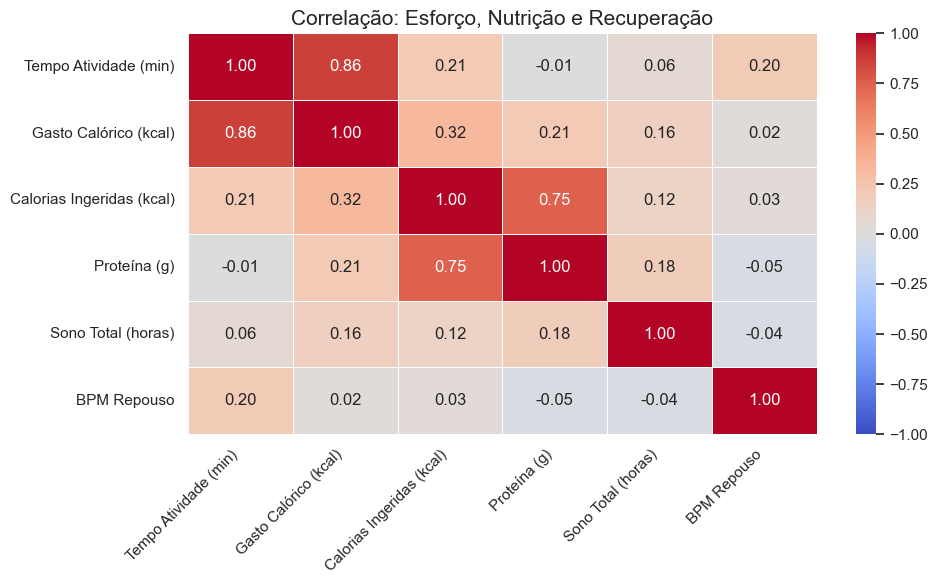

In [4]:
plt.figure(figsize=(10, 6))

# Filtrando colunas para o Heatmap não ficar poluído
colunas_para_correlacao = [
    'Tempo Atividade (min)', 
    'Gasto Calórico (kcal)',
    'Calorias Ingeridas (kcal)', 
    'Proteína (g)',
    'Sono Total (horas)', 
    'BPM Repouso'
]

# Método '.corr()' gera a matriz estatística (-1 a 1)
matriz_corr = df_final[colunas_para_correlacao].corr()

# Dica Visual: cmap='coolwarm' ajuda a ver Correlação Positiva (Vermelho) e Negativa (Azul)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlação: Esforço, Nutrição e Recuperação', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Insights Visuais

Explorando as hipóteses biológicas geradas pela Matriz.

### A. Impacto da Atividade no Sono

Usamos `pd.cut` para criar categorias de treino (Leve, Moderado, Intenso) e analisamos via **Boxplot**.

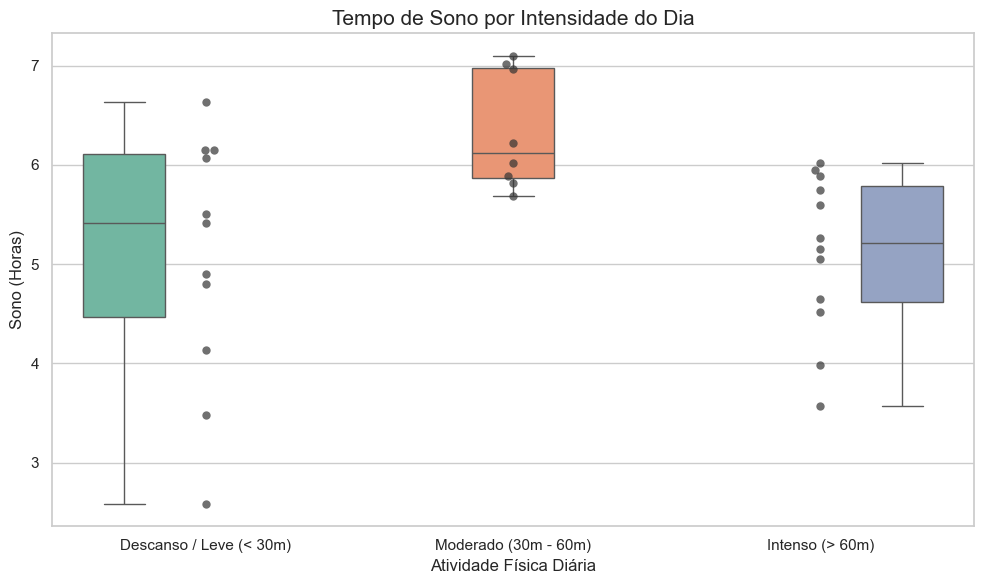

In [5]:
plt.figure(figsize=(10, 6))

# Engenharia de Atributos (Feature Engineering)
# Transformando uma variável contínua (minutos) em categórica (labels)
df_final['Categoria de Treino'] = pd.cut(
    df_final['Tempo Atividade (min)'],
    bins=[-1, 30, 60, df_final['Tempo Atividade (min)'].max() + 1],
    labels=['Descanso / Leve (< 30m)', 'Moderado (30m - 60m)', 'Intenso (> 60m)']
)

# Boxplot mostra a Mediana (linha do meio) e a Variância (tamanho da caixa)
sns.boxplot(
    data=df_final,
    x='Categoria de Treino',
    y='Sono Total (horas)',
    hue='Categoria de Treino',
    palette='Set2',
    legend=False,
    showfliers=False
)

# Dica: O Swarmplot plota cada "dia" individualmente por cima da caixa
sns.swarmplot(
    data=df_final, 
    x='Categoria de Treino', 
    y='Sono Total (horas)', 
    color=".2", 
    size=6, 
    alpha=0.7
)

plt.title('Tempo de Sono por Intensidade do Dia', fontsize=15)
plt.xlabel('Atividade Física Diária', fontsize=12)
plt.ylabel('Sono (Horas)', fontsize=12)
plt.tight_layout()
plt.show()